Using data from Yosemite Vallye from 2011-2016, I implement and compare Gaussian Processes from the Python GPy package (https://github.com/SheffieldML/GPy) and Ridge Regression from scikit-learn to predict the temperature in Yosemite for a time of the day and day of the year. 

# Data Preprocessing

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

years = range(2011, 2016)
files = ['CRNS0101-05-%d-CA_Yosemite_Village_12_W.txt' % y for y in years]
usecols = [1, 2, 8]

data = [np.loadtxt(f, usecols=usecols) for f in files]
data = np.vstack(data)

years_test = range(2016, 2017)
files_test = ['CRNS0101-05-%d-CA_Yosemite_Village_12_W.txt' % y for y in years_test]
usecols = [1, 2, 8]

data_test = [np.loadtxt(f, usecols=usecols) for f in files_test]
data_test = np.vstack(data_test)


# Map from HHmm to integer and conver it to a string
data[:, 1] = np.floor_divide(data[:, 1], 100) * 60 + np.mod(data[:, 1], 100)
valid = data[:, 2] > -1000

data_test[:, 1] = np.floor_divide(data_test[:, 1], 100) * 60 + np.mod(data_test[:, 1], 100)
valid_test = data_test[:, 2] > -1000

date = data[:,0][0:]
d_list = date.tolist()

date_list = []
for x in d_list[0:]:
    date_list.append(str(x))


date_test = data_test[:,0]
d_list_test = date_test.tolist()

date_list_test = []
for m in d_list_test[0:]:
    date_list_test.append(str(m))
     
date_list_ = []
date_list_test_ = []
def remove_end(liststs, empty_list):
    for s in liststs:
        empty_list.append(s[:-2])

remove_end(date_list, date_list_)
remove_end(date_list_test, date_list_test_)


import datetime
fmt = '%Y%m%d'

dt = []
for x in date_list_:
    dt.append(datetime.datetime.strptime(x, fmt))
    

dt_test = []
for date in date_list_test_:
    dt_test.append(datetime.datetime.strptime(date, fmt))
    
day_of_year = []
for num in dt:
    tt = num.timetuple()
    day_of_year.append(tt.tm_yday)
    
import numpy as np
year_day = np.asarray(day_of_year)


day_of_year_test = []
for num in dt_test:
    tt = num.timetuple()
    day_of_year_test.append(tt.tm_yday)
    
import numpy as np
year_day_test = np.asarray(day_of_year_test)

In [2]:
df = pd.DataFrame()
df["day"] = year_day
df["time"] = data[:, 1]
df["temp"] = data[:, 2]

df_test = pd.DataFrame()
df_test["day_test"] = year_day_test
df_test["time_test"] = data_test[:, 1]
df_test["temp_test"] = data_test[:, 2]

df = df[df.temp != -9999.0]

df_test = df_test[df_test.temp_test != -9999.0]

'''Reshaping and converting each column to an array '''
times = df.time.values.reshape(-1, 1)
temps = df.temp.values.reshape(-1, 1)
days = df.day.values.reshape(-1, 1)

train_time = np.array(times).reshape(-1,1)
train_temp = np.array(temps).reshape(-1,1)
train_day = np.array(days).reshape(-1,1)


times_test = df_test.time_test.values.reshape(-1, 1)
temps_test = df_test.temp_test.values.reshape(-1, 1)
days_test = df_test.day_test.values.reshape(-1, 1)

test_time = np.array(times_test).reshape(-1,1)
test_temp = np.array(temps_test).reshape(-1,1)
test_day = np.array(days_test).reshape(-1,1)

In [3]:
import GPy
from GPy.models import SparseGPRegression
import numpy as np
%matplotlib inline
np.random.seed(110797)

In [4]:
'''Defining better variable names to keep track of each contribution'''
x_train_day = train_day
y_train_temp = train_temp
x_test_day = test_day
y_test_temp = test_temp

# Ridge Regression

The following is using variables gamma and centers to define the variables for our rbf_kernel. The centers are placed within the space relative to their variable. Center1 uses the domain (0, 365) to have functions cover every day of the year, and center2 uses the domain (0, 1450) to cover ever minute in the day. The rbf_day and rbf_time variables store the output from running rbf_kernel on day and time, respectively. The output from each is a 1d by 6d variable, where the 6 dimensions are each of the distances from the center of the radial basis functions to the point. These are considered the weights, used later to build the ridge regression.

In [6]:
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.metrics import mean_squared_error
from sklearn.linear_model import Ridge
import matplotlib.pyplot as plt
import numpy as np

gamma_day = 1.0 / (120.0 **2)
gamma_time = 1.0 / (480**2)
center1 = np.linspace(0, 365, 6).reshape(-1, 1)
center2 = np.linspace(0,1450, 6).reshape(-1, 1)

rbf_day = rbf_kernel(days, center1, gamma = gamma_day)
rbf_time = rbf_kernel(times, center2, gamma = gamma_time)

# print x1, x2
# print x1.shape, x2.shape

In [7]:
# Create one variable x_training to hold each pair of (x1, x2) weights as a single variable
x_training = np.hstack((rbf_day, rbf_time))
y_training = temps

In [10]:
''' Fitting a ridge regression to x_train and y_train, for all three model measuring the output by regr.score'''
alpha_full = .01
regr = Ridge(alpha=alpha_full, fit_intercept=True)


full_model = regr.fit(x_training, y_training)
print("Score on training data for the full model: ", regr.score(x_training, y_training))

test_rbf_day = rbf_kernel(days_test, center1, gamma = gamma_day)
test_rbf_time = rbf_kernel(times_test, center2, gamma = gamma_time)

x_test = np.hstack((test_rbf_day, test_rbf_time))
y_pred = regr.predict(x_test)

print("Score on test data for the full model: ", regr.score(x_test, temps_test))
print("MSE: ", mean_squared_error(temps_test, y_pred))

('Score on training data for the full model: ', 0.61178872008822505)
('Score on test data for the full model: ', 0.62257037380989499)
('MSE: ', 22.887951865360296)


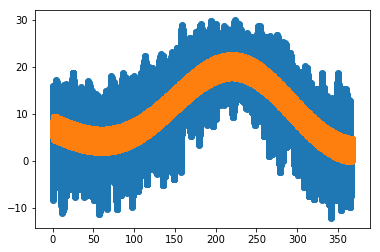

In [13]:
plt.figure()
plt.scatter(days, temps)
plt.scatter(days_test + times_test/1440, y_pred)
plt.show()

In [16]:
# Looking at the time component contribution
time_model = regr.fit(rbf_time, y_training)
time_pred = regr.predict(test_rbf_time)
print("Score on training data for the time model = ", regr.score(rbf_time, y_training))
print("Score on test data for the time model = ", regr.score(test_rbf_time, temps_test))
print("MSE: ", mean_squared_error(temps_test, time_pred))

('Score on training data for the time model = ', 0.044360817039578615)
('Score on test data for the time model = ', 0.044135371072281937)
('MSE: ', 57.965199599033646)


In [18]:
# Looking at the day component contribution
day_model = regr.fit(rbf_day, y_training)
day_pred = regr.predict(test_rbf_day)
print("Score on training data for the day model = ", regr.score(rbf_day, y_training))
print("Score on test data for the day model = ", regr.score(test_rbf_day, temps_test))
print("MSE: ", mean_squared_error(temps_test, day_pred))

('Score on training data for the day model = ', 0.56719572607957702)
('Score on test data for the day model = ', 0.57835062188074304)
('MSE: ', 25.569510183579926)


The scores for the time model, both training and test, were terrible – the model did a bad job predicting the temperature at a specific time. This makes sense, because it is not reasonable to build a predictive model for different times of day when the temperature at a specific time will be different between different days of the year. It is unreasonable to build a model to predict the temperature at 1pm every day when the temperature at 1pm is  different between July and December, or any other days more than a few months, or even weeks, apart throughout the year. The day model does a much better job predicting the temperature, which is more expected, as the temperature on December 1 will likely be pretty similar, or within a specific range, every year (queue climate change to destroy all of our models). 

# GPy Day of the Year Contribution

For all of the models shown below, I set the number of inducing points to 500 and the coveraince function to an RBF with lengthscale 100. To set the placement of inducing points I specify in the initial GPy model to find the optimal location and set those when later calling optimize() to find the other optimal hyperparameters.  

In [ ]:
plt.scatter(x_train_day, y_train_temp)

In [ ]:
'''Building the day of year GPy using an RBF kernel and 50 induction points'''
num_ind = 50
k = GPy.kern.RBF(input_dim=1, lengthscale = 100)
noise_var = 0.05
days_model = GPy.models.SparseGPRegression(x_train_day, 
                                  y_train_temp, 
                                  kernel = k,
                                  num_inducing=num_ind)
days_model.likelihood.variance = noise_var
days_model.plot(plot_limits=[0, 365])
days_model.plot(plot_data = False, plot_limits=[0, 365])
print days_model

In [ ]:
from sklearn.metrics import mean_squared_error
pred = days_model.predict(x_test_day)
mean_squared_error(y_test_temp, pred[0])

The above shows the Gaussian Sparse Process model for the temperature in Yosemite on a given day of the year. The first plot shows the model with the data, so as to compare the basic trend of the data throughout the year, with the most basic GPy model. 

In [ ]:
'''Optimizing the hyperparameters, except the inducing inputs for the day of year'''
days_model.inducing_inputs.fix()
days_model.optimize("bfgs")
days_model.plot(plot_data = True, plot_limits=[0, 365])
print days_model

In [ ]:
from sklearn.metrics import mean_squared_error
pred = days_model.predict(x_test_day)
mean_squared_error(y_test_temp, pred[0])

The initial graph was intuitively very nice, but I hadn't done anything to optimize the hyperparameters (length scale, variance, etc.). By calling days_model.optimize the program is running type 2 maximum likelihood, finding the optimal values for the aforementioned hyperparameters. Without any specified inputs, it restarts 10 times so as to avoid falling at a local maximum. 

# GPy Time of Day Contribution

In [14]:
x_train_time = train_time
y_train_temp = train_temp
x_test_time = test_time
y_test_temp = test_temp


Name : sparse_gp
Objective : 307271871.025
Number of Parameters : 53
Number of Optimization Parameters : 53
Updates : True
Parameters:
  sparse_gp.               |    value  |  constraints  |  priors
  inducing_inputs          |  (50, 1)  |               |        
  rbf.variance             |      1.0  |      +ve      |        
  rbf.lengthscale          |    100.0  |      +ve      |        
  Gaussian_noise.variance  |     0.05  |      +ve      |        


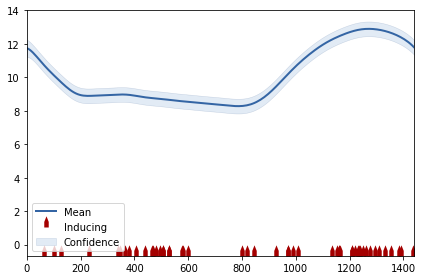

In [15]:
'''Building the time of day GPy using an RBF kernel and 50 induction points'''
num_ind = 50
k = GPy.kern.RBF(input_dim=1, lengthscale = 100)
noise_var = 0.05
time_model = GPy.models.SparseGPRegression(x_train_time, 
                                           y_train_temp, 
                                           kernel = k,
                                           num_inducing=num_ind)
time_model.likelihood.variance = noise_var
time_model.plot(plot_data = False, plot_limits=[0,1440])
print time_model

In [16]:
from sklearn.metrics import mean_squared_error
pred = time_model.predict(x_test_time)
mean_squared_error(y_test_temp, pred[0])

57.955971729642208


Name : sparse_gp
Objective : 1814920.8119
Number of Parameters : 53
Number of Optimization Parameters : 3
Updates : True
Parameters:
  sparse_gp.               |          value  |  constraints  |  priors
  inducing_inputs          |        (50, 1)  |     fixed     |        
  rbf.variance             |  196.152592097  |      +ve      |        
  rbf.lengthscale          |  253.618545585  |      +ve      |        
  Gaussian_noise.variance  |  58.5338792142  |      +ve      |        


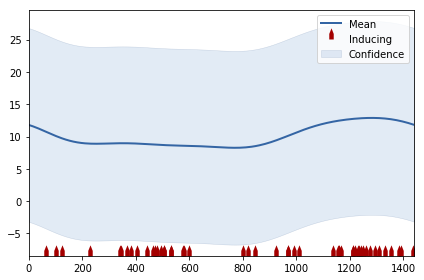

In [17]:
'''Optimizing the hyperparameters, except the inducing inputs for the time of day'''
time_model.inducing_inputs.fix()
time_model.optimize("bfgs")
time_model.plot(plot_data = False, plot_limits=[0,1440])
print time_model

In [18]:
from sklearn.metrics import mean_squared_error
pred = time_model.predict(x_test_time)
mean_squared_error(y_test_temp, pred[0])

57.956515239965363

The time contribution is modeled the exact same way the day contribution is modeled above. The same issue happens wherein the optimization does not decrease the MSE – they both hover around 57.95 – which is close to that from the previous LPM – 57.965. As discussed in the previous paper, this is an expected result because it is not reasonable to build a predictive model for different times of the day when the temperature at a specific time will be different between different days of the year. It is unreasonable to build a model to predict the temperature at 1pm every day when the temperature at 1pm is different between July and December, or any other days more than a few months, or even weeks, apart throughout the year. The day model does a much better job predicting the temperature, which is more expected, as the temperature on December 1 will likely be pretty similar, or within a specific range, every year (queue climate change to destroy all of our models).

# GPy Full Model (Time and Day)

In [6]:
x_train = df[['day','time']].as_matrix()
x_test = df_test[['day_test', 'time_test']].as_matrix()

In [9]:
len(x_train)

525480


Name : sparse_gp
Objective : 128170484.926
Number of Parameters : 103
Number of Optimization Parameters : 103
Updates : True
Parameters:
  sparse_gp.               |    value  |  constraints  |  priors
  inducing_inputs          |  (50, 2)  |               |        
  rbf.variance             |      1.0  |      +ve      |        
  rbf.lengthscale          |    100.0  |      +ve      |        
  Gaussian_noise.variance  |     0.05  |      +ve      |        


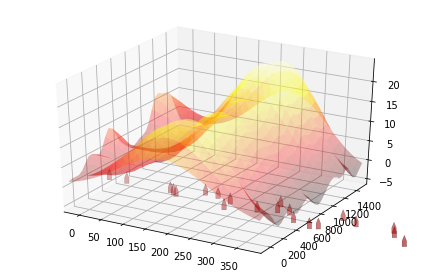

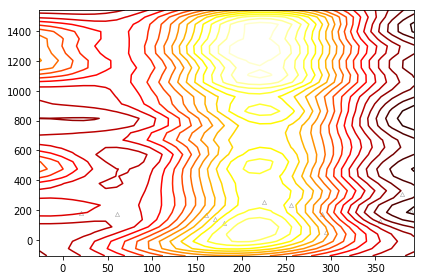

In [20]:
'''Building the Full GPy using an RBF kernel and 50 induction points'''
num_ind = 50
full_k = GPy.kern.RBF(input_dim=2, lengthscale = 100)
noise_var = 0.05
full_model = GPy.models.SparseGPRegression(x_train, 
                                  y_train_temp, 
                                  kernel = full_k,
                                  num_inducing=num_ind)
full_model.likelihood.variance = noise_var
full_model.plot(plot_data = False, projection = "3d", legend = False)
full_model.plot(plot_data = False, legend = False)
print full_model

In [21]:
from sklearn.metrics import mean_squared_error
pred_full = full_model.predict(x_test)
mean_squared_error(y_test_temp, pred_full[0])

22.818893719293559


Name : sparse_gp
Objective : 1576088.1519
Number of Parameters : 103
Number of Optimization Parameters : 103
Updates : True
Parameters:
  sparse_gp.               |          value  |  constraints  |  priors
  inducing_inputs          |        (50, 2)  |               |        
  rbf.variance             |  9.05593543028  |      +ve      |        
  rbf.lengthscale          |  124.173286248  |      +ve      |        
  Gaussian_noise.variance  |  23.5205178971  |      +ve      |        


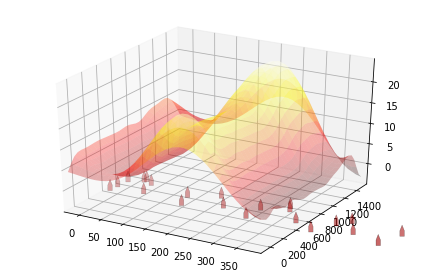

In [23]:
'''Optimizing the hyperparameters, except the inducing inputs for the full model'''
days_model.inducing_inputs.fix()
full_model.optimize("bfgs")
full_model.plot(plot_data = False, projection = "3d", legend = False)
print full_model

In [25]:
from sklearn.metrics import mean_squared_error
pred_full = full_model.predict(x_test)
mean_squared_error(y_test_temp, pred_full[0])

22.563665274481522

This is where the time and day contribute to the predictions of temperature. Without seeing the optimized version (as it takes over 20 minutes to run), the initial model outputs an MSE of 22.818, slighter smaller than that of the LPM – 22.8879. The 3D and contour plot follows trends we would expect from a plot predicting temperature. They show that the temperature is highest during the beginning of the last third of the year (middle of August), and lowest between December and mid-Febraury. The time prediction, however, is a bit more off – the hottest times of the day are predicted closer to the beginningand very end of the day (seen in the peaks and short distance between contours at those points). 

The time comparisons, between LPM and GP, were limited, because I didn't leave enough time to rerun everything before submission. The training time for the full model of LPM was reported by Guy as 3.1, compared to the full GP model witha run time of 9.27 (as shown by Eynat). The times for optimization, again reported by Eynat, were between 200 and 700 seconds, much larger than any time required to train or optimize LPM last week. In the future, these numbers need to be more quantitative, relying on true results for the models I used to compare the MSE should be the model used to compare run times. Given my experiences running both of these models, however, I would recommend using an LPM for this task, as is it gives a comparable, and often better, MSE, in a much shorter time necessary for training. 

Overall, this data set as we have modeled it doesn't need a gaussian process to create a strong, or well predicting, model. Gaussian Processes typically work best for data that must be fit locally – as seen in the traditional CO2 example showing small trends over the seasons in each year, and a long term trend over the years. This data set could be changed to take advantage of GP by modeling the time of the day, for every day, over the course of a few years. This might be interesting to plot next to a graph of changing CO2, viewing an interaction in their trends overall, or seasonaly, both variables which could be well modeled with GP than a LPM.